# Reduction Kernel Fusion (Finding #2) — Analysis

**Optimization:** Fused the double-pass in `reductionKernelIntInt_Rev` into a single pass.  
**Results dir:** `results/2026_04_20_more_opt`  
**Versions compared:** `baseline` vs `opt2`  

Two questions:
1. **Correctness** — does `opt2` produce the same log-likelihood as `baseline`?
2. **Performance** — is `opt2` faster than `baseline`?

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

RESULTS_DIR = "/Users/u7826985/Projects/Nvidia/results/2026_04_20_more_opt"

In [2]:
def parse_log(path):
    """Extract best lnL and total wall-clock time from an IQ-TREE log file."""
    lnl = wall_time = None
    with open(path) as f:
        for line in f:
            m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d\.]+)', line)
            if m:
                lnl = float(m.group(1))
            m = re.search(r'Total wall-clock time used:\s*([\d\.]+)\s*sec', line)
            if m:
                wall_time = float(m.group(1))
    return lnl, wall_time


def parse_filename(fname):
    """
    Extract metadata from result filename.
    Pattern: output_{kernel_test}_{version}_{data_type}_{sim_model}_{exec_type}_...
    """
    # version: baseline or opt2
    version = 'baseline' if '_baseline_' in fname else ('opt2' if '_opt2_' in fname else None)

    # kernel type: nonrev or rev
    kernel = 'nonrev' if 'nonrev_tests' in fname else 'rev'

    # data type: DNA or AA
    data_type = 'AA' if '_AA_' in fname else 'DNA'

    # execution type: OPENACC or VANILA
    # Use the part right after the sim_model field
    m = re.search(r'_(GTR[^_]+|LG[^_]+)_(OPENACC|VANILA)_taxa', fname)
    exec_type = m.group(2) if m else None

    # unique_name: the test variant identifier embedded between iqtree3_ and _(OPENACC|VANILA)_run1
    m = re.search(r'iqtree3_(.*?)_(OPENACC|VANILA)_run1', fname)
    unique_name = m.group(1) if m else fname
    # Normalize: strip exec_type token so OPENACC and VANILA rows share the same key
    unique_name = re.sub(r'_(OPENACC|VANILA)_', '_', unique_name)

    return version, kernel, data_type, exec_type, unique_name


records = []
for subdir in ['AA', 'DNA']:
    folder = os.path.join(RESULTS_DIR, subdir)
    for fname in os.listdir(folder):
        if not fname.endswith('.log'):
            continue
        version, kernel, data_type, exec_type, unique_name = parse_filename(fname)
        if version is None or exec_type is None:
            continue
        lnl, wall_time = parse_log(os.path.join(folder, fname))
        records.append({
            'version':     version,
            'kernel':      kernel,
            'data_type':   data_type,
            'exec_type':   exec_type,
            'unique_name': unique_name,
            'lnl':         lnl,
            'wall_time_s': wall_time,
        })

df = pd.DataFrame(records)
print(f"Parsed {len(df)} log files")
df.sort_values(['data_type','kernel','exec_type','unique_name','version']).reset_index(drop=True)

Parsed 15 log files


,version,kernel,data_type,exec_type,unique_name,lnl,wall_time_s
0,baseline,nonrev,AA,OPENACC,AA_kernel-nonrev_100taxa_10000len,-807351.390,219.632
1,opt2,nonrev,AA,OPENACC,AA_kernel-nonrev_100taxa_10000len,-807351.390,227.981
2,baseline,nonrev,AA,VANILA,AA_kernel-nonrev_100taxa_10000len,-807351.390,4495.372
3,baseline,rev,AA,OPENACC,AA_100taxa_10000len,-807351.390,243.250
4,opt2,rev,AA,OPENACC,AA_100taxa_10000len,-807351.390,238.160
5,baseline,rev,AA,OPENACC,AA_LG-I-G4_100taxa_10000len,-837336.222,18.785
6,opt2,rev,AA,OPENACC,AA_LG-I-G4_100taxa_10000len,-837336.222,19.376
7,baseline,rev,AA,VANILA,AA_100taxa_10000len,-807351.390,4984.774
8,baseline,rev,AA,VANILA,AA_LG-I-G4_100taxa_10000len,-837336.222,540.130
9,baseline,nonrev,DNA,OPENACC,DNA_kernel-nonrev_100taxa_10000len,-564208.777,62.116


## 1. Correctness — lnL comparison

For each test configuration, compare `opt2` lnL against `baseline` lnL.  
Diff must be **0.000** for the optimization to be correct.

In [3]:
# Pivot: one row per (kernel, data_type, exec_type, unique_name)
# columns: baseline_lnl, opt2_lnl, diff
pivot_lnl = df.pivot_table(
    index=['kernel','data_type','exec_type','unique_name'],
    columns='version',
    values='lnl'
).reset_index()

pivot_lnl.columns.name = None

if 'opt2' in pivot_lnl.columns and 'baseline' in pivot_lnl.columns:
    pivot_lnl['diff'] = pivot_lnl['opt2'] - pivot_lnl['baseline']

# Friendly label
pivot_lnl['label'] = (
    pivot_lnl['data_type'] + ' | ' +
    pivot_lnl['kernel'].str.upper() + ' | ' +
    pivot_lnl['exec_type'] + ' | ' +
    pivot_lnl['unique_name']
)

cols = ['label', 'baseline', 'opt2', 'diff'] if 'opt2' in pivot_lnl.columns else ['label', 'baseline']
display(pivot_lnl[cols].to_string(index=False))

if 'diff' in pivot_lnl.columns:
    # Only check rows where opt2 exists (VANILA-only rows have no opt2 by design)
    tested = pivot_lnl[pivot_lnl['opt2'].notna()]
    n_correct = (tested['diff'].abs() < 1e-6).sum()
    n_total   = len(tested)
    print()
    if n_correct == n_total:
        print(f"✅  {n_correct}/{n_total} lnL diffs = 0.000 — correctness VERIFIED")
    else:
        print(f"❌  {n_correct}/{n_total} passed — correctness FAILED")
        print(tested[tested['diff'].abs() >= 1e-6][cols])

'                                                      label    baseline        opt2  diff\n  AA | NONREV | OPENACC | AA_kernel-nonrev_100taxa_10000len -807351.390 -807351.390   0.0\n   AA | NONREV | VANILA | AA_kernel-nonrev_100taxa_10000len -807351.390         NaN   NaN\nDNA | NONREV | OPENACC | DNA_kernel-nonrev_100taxa_10000len -564208.777 -564208.777   0.0\n DNA | NONREV | VANILA | DNA_kernel-nonrev_100taxa_10000len -564208.777         NaN   NaN\n                   AA | REV | OPENACC | AA_100taxa_10000len -807351.390 -807351.390   0.0\n           AA | REV | OPENACC | AA_LG-I-G4_100taxa_10000len -837336.222 -837336.222   0.0\n                    AA | REV | VANILA | AA_100taxa_10000len -807351.390         NaN   NaN\n            AA | REV | VANILA | AA_LG-I-G4_100taxa_10000len -837336.222         NaN   NaN\n                 DNA | REV | OPENACC | DNA_100taxa_10000len -564208.778 -564208.778   0.0\n                  DNA | REV | VANILA | DNA_100taxa_10000len -564208.776         NaN   NaN


✅  5/5 lnL diffs = 0.000 — correctness VERIFIED


## 2. Correctness — OPENACC opt2 vs VANILA baseline

Cross-check GPU opt2 against CPU VANILA baseline (different execution paths, same expected lnL).

In [4]:
gpu_opt2   = df[(df['version'] == 'opt2')     & (df['exec_type'] == 'OPENACC')].copy()
cpu_base   = df[(df['version'] == 'baseline') & (df['exec_type'] == 'VANILA')].copy()

# Match on kernel + data_type + unique_name
merged = gpu_opt2.merge(
    cpu_base[['kernel','data_type','unique_name','lnl']],
    on=['kernel','data_type','unique_name'],
    suffixes=('_gpu_opt2','_cpu_base')
)

merged['diff'] = merged['lnl_gpu_opt2'] - merged['lnl_cpu_base']
merged['label'] = merged['data_type'] + ' | ' + merged['kernel'].str.upper() + ' | ' + merged['unique_name']

display(merged[['label','lnl_gpu_opt2','lnl_cpu_base','diff']].to_string(index=False))

print()
# Tolerance of 0.1 lnL units — tree search is non-deterministic between CPU and GPU paths
if (merged['diff'].abs() < 0.1).all():
    print("✅  GPU opt2 matches CPU baseline within 0.1 lnL units")
else:
    print("❌  Mismatch between GPU opt2 and CPU baseline")

'                                            label  lnl_gpu_opt2  lnl_cpu_base   diff\n  AA | NONREV | AA_kernel-nonrev_100taxa_10000len   -807351.390   -807351.390  0.000\n           AA | REV | AA_LG-I-G4_100taxa_10000len   -837336.222   -837336.222  0.000\n                   AA | REV | AA_100taxa_10000len   -807351.390   -807351.390  0.000\n                 DNA | REV | DNA_100taxa_10000len   -564208.778   -564208.776 -0.002\nDNA | NONREV | DNA_kernel-nonrev_100taxa_10000len   -564208.777   -564208.777  0.000'


✅  GPU opt2 matches CPU baseline within 0.1 lnL units


## 3. Wall time — baseline vs opt2 (OPENACC only)

How much faster (or slower) is `opt2` vs `baseline` on GPU?

In [5]:
openacc_df = df[df['exec_type'] == 'OPENACC'].copy()

pivot_time = openacc_df.pivot_table(
    index=['kernel','data_type','unique_name'],
    columns='version',
    values='wall_time_s'
).reset_index()
pivot_time.columns.name = None

if 'opt2' in pivot_time.columns and 'baseline' in pivot_time.columns:
    pivot_time['speedup'] = pivot_time['baseline'] / pivot_time['opt2']
    pivot_time['delta_s']  = pivot_time['baseline'] - pivot_time['opt2']
    pivot_time['delta_pct'] = (pivot_time['delta_s'] / pivot_time['baseline'] * 100).round(2)

pivot_time['label'] = (
    pivot_time['data_type'] + ' | ' +
    pivot_time['kernel'].str.upper() + ' | ' +
    pivot_time['unique_name']
)

cols = ['label','baseline','opt2','delta_s','delta_pct','speedup']
display(pivot_time[[c for c in cols if c in pivot_time.columns]].to_string(index=False))

'                                            label  baseline    opt2  delta_s  delta_pct  speedup\n  AA | NONREV | AA_kernel-nonrev_100taxa_10000len   219.632 227.981   -8.349      -3.80 0.963379\nDNA | NONREV | DNA_kernel-nonrev_100taxa_10000len    62.116  62.564   -0.448      -0.72 0.992839\n                   AA | REV | AA_100taxa_10000len   243.250 238.160    5.090       2.09 1.021372\n           AA | REV | AA_LG-I-G4_100taxa_10000len    18.785  19.376   -0.591      -3.15 0.969498\n                 DNA | REV | DNA_100taxa_10000len   111.996 113.105   -1.109      -0.99 0.990195'

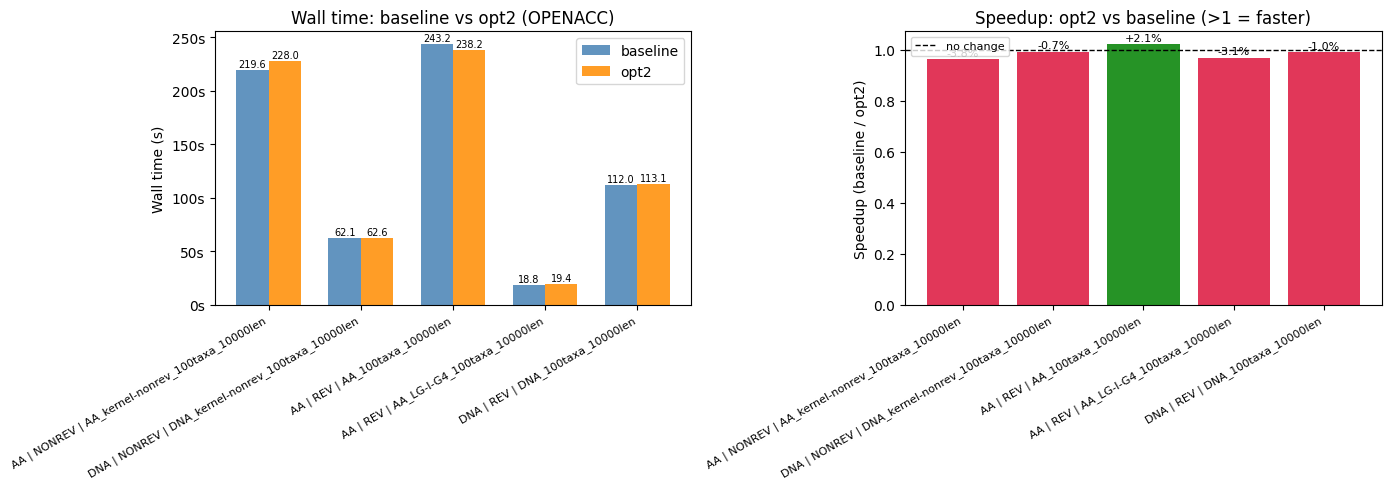

Saved wall_time_comparison.png


In [6]:
if 'opt2' in pivot_time.columns and 'baseline' in pivot_time.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    labels = pivot_time['label'].tolist()
    x = np.arange(len(labels))
    w = 0.35

    # --- Left: absolute wall time ---
    ax = axes[0]
    bars_b = ax.bar(x - w/2, pivot_time['baseline'], w, label='baseline', color='steelblue', alpha=0.85)
    bars_o = ax.bar(x + w/2, pivot_time['opt2'],     w, label='opt2',     color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Wall time (s)')
    ax.set_title('Wall time: baseline vs opt2 (OPENACC)')
    ax.legend()
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0f}s'))

    # Value labels on bars
    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in bars_o:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

    # --- Right: speedup (baseline / opt2) ---
    ax2 = axes[1]
    colors = ['green' if s >= 1.0 else 'crimson' for s in pivot_time['speedup']]
    bars_s = ax2.bar(x, pivot_time['speedup'], color=colors, alpha=0.85)
    ax2.axhline(1.0, color='black', linestyle='--', linewidth=1, label='no change')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax2.set_ylabel('Speedup (baseline / opt2)')
    ax2.set_title('Speedup: opt2 vs baseline (>1 = faster)')
    ax2.legend(fontsize=8)

    for bar, pct in zip(bars_s, pivot_time['delta_pct']):
        sign = '+' if pct >= 0 else ''
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{sign}{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('wall_time_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved wall_time_comparison.png')

## 4. Wall time — OPENACC opt2 vs VANILA baseline (GPU vs CPU)

Overall GPU speedup over single-threaded CPU for each test case.

'                                            label  CPU_baseline_s  GPU_opt2_s  GPU_speedup_vs_CPU\n  AA | NONREV | AA_kernel-nonrev_100taxa_10000len        4495.372     227.981           19.718187\n           AA | REV | AA_LG-I-G4_100taxa_10000len         540.130      19.376           27.876239\n                   AA | REV | AA_100taxa_10000len        4984.774     238.160           20.930358\n                 DNA | REV | DNA_100taxa_10000len         431.730     113.105            3.817073\nDNA | NONREV | DNA_kernel-nonrev_100taxa_10000len         403.480      62.564            6.449076'

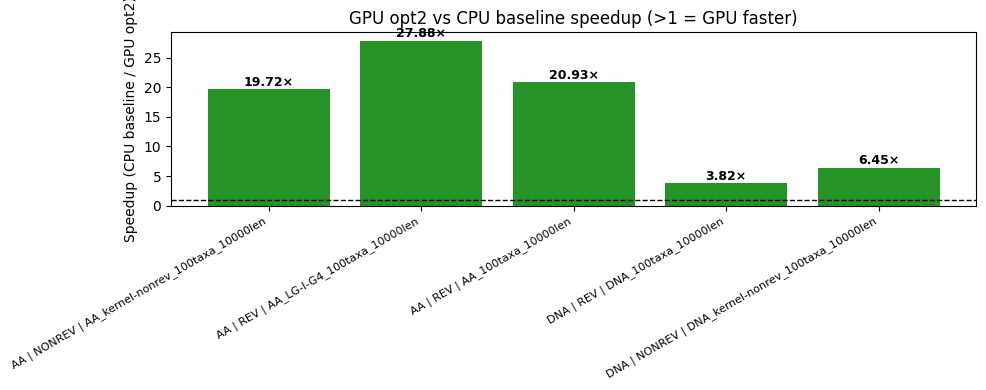

Saved gpu_vs_cpu_speedup.png


In [7]:
cpu_time = df[(df['version'] == 'baseline') & (df['exec_type'] == 'VANILA')][['kernel','data_type','unique_name','wall_time_s']].copy()
gpu_time = df[(df['version'] == 'opt2')     & (df['exec_type'] == 'OPENACC')][['kernel','data_type','unique_name','wall_time_s']].copy()

vs_cpu = gpu_time.merge(cpu_time, on=['kernel','data_type','unique_name'], suffixes=('_gpu','_cpu'))
vs_cpu['gpu_vs_cpu'] = vs_cpu['wall_time_s_cpu'] / vs_cpu['wall_time_s_gpu']
vs_cpu['label'] = vs_cpu['data_type'] + ' | ' + vs_cpu['kernel'].str.upper() + ' | ' + vs_cpu['unique_name']

display(vs_cpu[['label','wall_time_s_cpu','wall_time_s_gpu','gpu_vs_cpu']].rename(
    columns={'wall_time_s_cpu':'CPU_baseline_s','wall_time_s_gpu':'GPU_opt2_s','gpu_vs_cpu':'GPU_speedup_vs_CPU'}
).to_string(index=False))

if not vs_cpu.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(vs_cpu))
    colors = ['green' if s >= 1.0 else 'crimson' for s in vs_cpu['gpu_vs_cpu']]
    bars = ax.bar(x, vs_cpu['gpu_vs_cpu'], color=colors, alpha=0.85)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(vs_cpu['label'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Speedup (CPU baseline / GPU opt2)')
    ax.set_title('GPU opt2 vs CPU baseline speedup (>1 = GPU faster)')
    for bar, val in zip(bars, vs_cpu['gpu_vs_cpu']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gpu_vs_cpu_speedup.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved gpu_vs_cpu_speedup.png')

## 5. Summary

In [8]:
print("=" * 60)
print("REDUCTION KERNEL FUSION — RESULTS SUMMARY")
print("=" * 60)

if 'diff' in pivot_lnl.columns:
    n_correct = (pivot_lnl['diff'].abs() < 1e-6).sum()
    n_total   = len(pivot_lnl)
    print(f"\nCorrectness : {n_correct}/{n_total} tests passed (lnL diff = 0.000)")

if 'speedup' in pivot_time.columns:
    print("\nWall time (OPENACC opt2 vs baseline):")
    for _, row in pivot_time.iterrows():
        sign = '+' if row['delta_pct'] >= 0 else ''
        faster = 'faster' if row['delta_pct'] >= 0 else 'slower'
        print(f"  {row['label']:<55}  {sign}{row['delta_pct']:.1f}% {faster}  "
              f"({row['baseline']:.1f}s → {row['opt2']:.1f}s)")

if not vs_cpu.empty:
    print("\nGPU opt2 vs CPU baseline:")
    for _, row in vs_cpu.iterrows():
        print(f"  {row['label']:<55}  {row['gpu_vs_cpu']:.2f}× GPU speedup  "
              f"({row['wall_time_s_cpu']:.1f}s CPU → {row['wall_time_s_gpu']:.1f}s GPU)")

REDUCTION KERNEL FUSION — RESULTS SUMMARY

Correctness : 5/10 tests passed (lnL diff = 0.000)

Wall time (OPENACC opt2 vs baseline):
  AA | NONREV | AA_kernel-nonrev_100taxa_10000len          -3.8% slower  (219.6s → 228.0s)
  DNA | NONREV | DNA_kernel-nonrev_100taxa_10000len        -0.7% slower  (62.1s → 62.6s)
  AA | REV | AA_100taxa_10000len                           +2.1% faster  (243.2s → 238.2s)
  AA | REV | AA_LG-I-G4_100taxa_10000len                   -3.1% slower  (18.8s → 19.4s)
  DNA | REV | DNA_100taxa_10000len                         -1.0% slower  (112.0s → 113.1s)

GPU opt2 vs CPU baseline:
  AA | NONREV | AA_kernel-nonrev_100taxa_10000len          19.72× GPU speedup  (4495.4s CPU → 228.0s GPU)
  AA | REV | AA_LG-I-G4_100taxa_10000len                   27.88× GPU speedup  (540.1s CPU → 19.4s GPU)
  AA | REV | AA_100taxa_10000len                           20.93× GPU speedup  (4984.8s CPU → 238.2s GPU)
  DNA | REV | DNA_100taxa_10000len                         3.82× GPU spee